 # NSL-KDD Intrusion Detection - Data Preprocessing & ML Models
 
 
 ## import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.decomposition import PCA
import seaborn as sns

In [14]:
#loading dataset
path = r"C:/Users/Hp/OneDrive/Documents/Desktop/web/SentinelNet/data/NSL-KDD/KDDTrain+.txt"
df_train = pd.read_csv(path, header=None,low_memory=False)
file= r"C:/Users/Hp/OneDrive/Documents/Desktop/web/SentinelNet/data/NSL-KDD/KDDTest+.txt"
df_test=pd.read_csv(file, header=None,low_memory=False)
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# Add column names

In [15]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]

df_train.columns = columns
df_test.columns  = columns
print("Train shape:", df_train.shape)
print(df_train.head())

Train shape: (125973, 43)
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                     

# Handling missing values

In [16]:
print(df_train.isnull().sum().sum(), "missing values.")

df_train = df_train.dropna()

0 missing values.


# Data Cleaning

In [17]:
print("Missing values in train set:", df_train.isnull().sum().sum())
print("Missing values in test set:", df_test.isnull().sum().sum())
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)
before_train = df_train.shape[0]
df_train.drop_duplicates(inplace=True)
print(f"Removed {before_train - df_train.shape[0]} duplicates from train set. New shape: {df_train.shape}")

before_test = df_test.shape[0]
df_test.drop_duplicates(inplace=True)
print(f"Removed {before_test - df_test.shape[0]} duplicates from test set. New shape: {df_test.shape}")
df_train['attack_binary'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['attack_binary'] = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)


Missing values in train set: 0
Missing values in test set: 42
Removed 0 duplicates from train set. New shape: (125973, 43)
Removed 0 duplicates from test set. New shape: (22544, 43)


#  Exploratory Data Analysis (EDA)

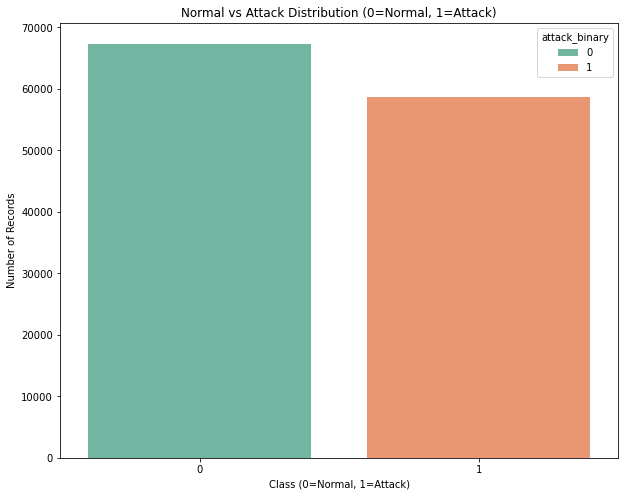

In [18]:
plt.figure(figsize=(10,8))
sns.countplot(x='attack_binary', data=df_train, hue='attack_binary', palette="Set2", dodge=False)
plt.title("Normal vs Attack Distribution (0=Normal, 1=Attack)", fontsize=12)
plt.xlabel("Class (0=Normal, 1=Attack)")
plt.ylabel("Number of Records")
plt.show()

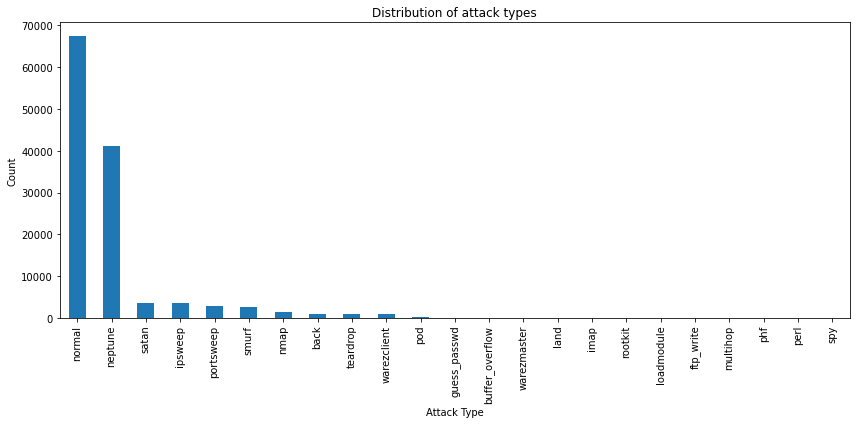

In [19]:
label_count = df_train['label'].value_counts()
plt.figure(figsize=(12,6))
label_count.plot(kind='bar')
plt.title('Distribution of attack types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

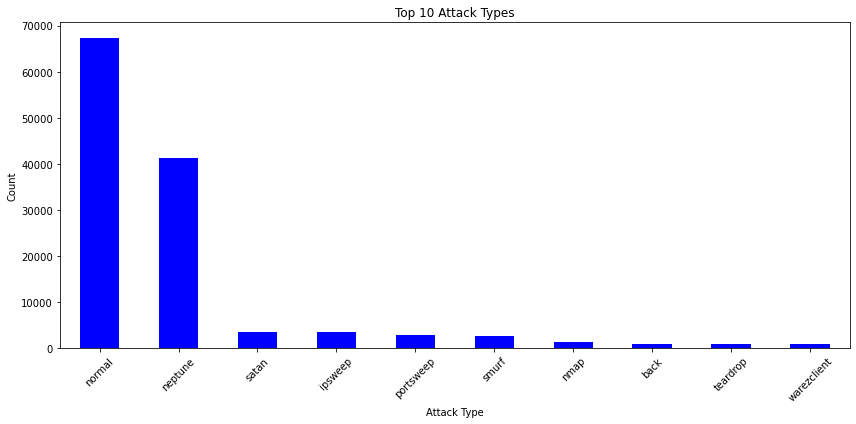

In [20]:
 attack_col = 'label' 
top_attacks = df_train[attack_col].value_counts().head(10)
plt.figure(figsize=(12,6))
top_attacks.plot(kind='bar', color='blue')
plt.title('Top 10 Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

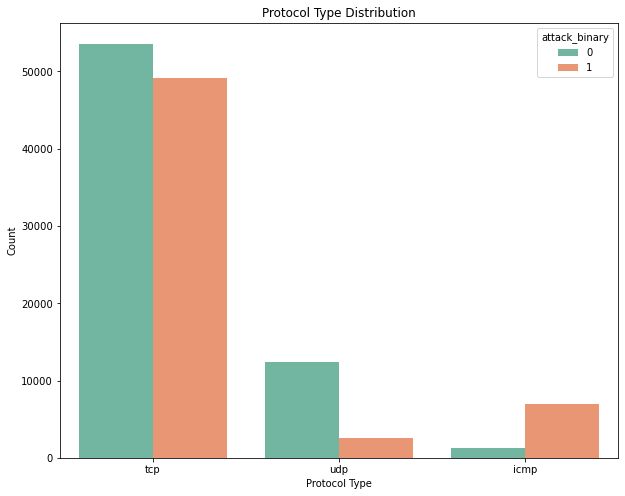

In [21]:
plt.figure(figsize=(10,8))
sns.countplot(x='protocol_type', data=df_train, hue='attack_binary', palette="Set2")
plt.title("Protocol Type Distribution", fontsize=12)
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.show()

In [41]:
#Separate features and target
exclude_cols = ['label', 'difficulty_level', 'attack_binary']
categorical_cols = ['protocol_type', 'service', 'flag']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + exclude_cols]
X_train = df_train[numeric_cols + categorical_cols]
y_train = df_train['attack_binary']

X_test = df_test[numeric_cols + categorical_cols]
y_test = df_test['attack_binary']


In [54]:
#One-hot encode categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
X_train_encoded = pd.DataFrame(
    encoder.fit_transform(X_train[categorical_cols]),
    index=X_train.index,
    columns=encoder.get_feature_names(categorical_cols)  # <- use get_feature_names here
)

X_test_encoded = pd.DataFrame(
    encoder.transform(X_test[categorical_cols]),
    index=X_test.index,
    columns=encoder.get_feature_names(categorical_cols)
)
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]
X_train_final = pd.concat([X_train[numeric_cols].reset_index(drop=True),
                           X_train_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test[numeric_cols].reset_index(drop=True),
                          X_test_encoded.reset_index(drop=True)], axis=1)

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)


X_train_final shape: (125973, 122)
X_test_final shape: (22544, 122)


In [78]:
# feature scaling
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=X_train_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns)
y_train = df_train['attack_binary']
y_test = df_test['attack_binary']

# Remove highly correlated features

In [79]:
corr_matrix = X_train_split.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Dropping highly correlated features:", to_drop)

X_train_split = X_train_split.drop(columns=to_drop)
X_val_split = X_val_split.drop(columns=to_drop)
X_test_scaled = X_test_scaled.drop(columns=to_drop)


Dropping highly correlated features: []


# Train-test split

In [80]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)



# PCA

In [123]:
pca = PCA(n_components=100, random_state=42)

X_train_pca = pca.fit_transform(X_train_split)
X_val_pca = pca.transform(X_val_split)
X_test_pca = pca.transform(X_test_scaled)


# ML algorithms

1. Supervised Learning

2. Unsupervised Learning

3. Semi-Supervised Learning

4. Reinforcement Learning

5. Ensemble Learning

# Practice with simple examples
## predicting house prices:


In [124]:
# import linear regression 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = {
    'Size(sqft)': [750, 800, 1200, 1500, 1800, 2000],
    'Bedrooms': [2, 2, 3, 3, 4, 4],
    'Age': [10, 15, 20, 5, 8, 12],
    'Price': [150000, 160000, 200000, 250000, 300000, 320000]
}

df = pd.DataFrame(data)
X = df[['Size(sqft)', 'Bedrooms', 'Age']]
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Predicted Prices:", y_pred)
print("Mean Squared Error:", mse)
new_house = [[1600, 3, 10]] 
predicted_price = model.predict(new_house)
print("Predicted Price for new house:", predicted_price[0])


Predicted Prices: [138809.52380952 140000.        ]
Mean Squared Error: 262613378.684809
Predicted Price for new house: 257142.85714285713


## Customer segmentation :

   CustomerID  AnnualIncome(k$)  SpendingScore  Cluster
0           1                15             39        0
1           2                16             81        1
2           3                45              6        0
3           4                55             77        1
4           5                85             40        2
5           6                90             76        2
6           7               120             20        2
7           8               130             94        2


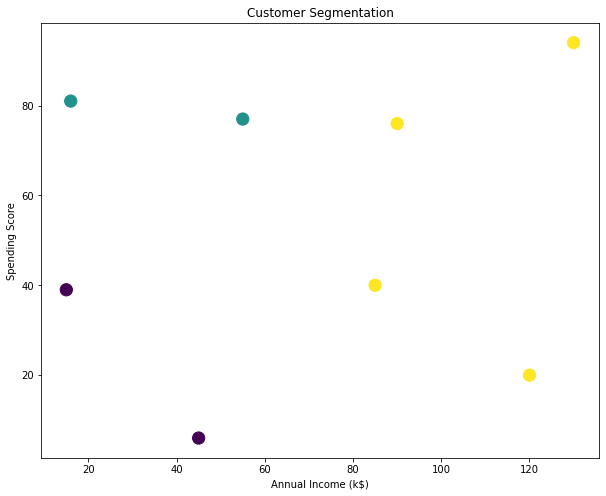

In [125]:
from sklearn.cluster import KMeans
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8],
    'AnnualIncome(k$)': [15, 16, 45, 55, 85, 90, 120, 130],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 20, 94]
}

df = pd.DataFrame(data)
X = df[['AnnualIncome(k$)', 'SpendingScore']]
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
df['Cluster'] = kmeans.labels_
print(df)
plt.figure(figsize=(10, 8))
plt.scatter(df['AnnualIncome(k$)'], df['SpendingScore'], c=df['Cluster'], cmap='viridis',s=150)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation')
plt.show()

# Power Transformation to Normalize Data

In [126]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')  
X_train_power = pt.fit_transform(X_train_pca)
X_test_power = pt.transform(X_test_pca)


 # KMeans Clustering

In [127]:
kmeans = KMeans(n_clusters=5, random_state=42)
train_clusters = kmeans.fit_predict(X_train_power)
test_clusters = kmeans.predict(X_test_power)

X_train_power = np.concatenate([X_train_power, train_clusters.reshape(-1,1)], axis=1)
X_test_power = np.concatenate([X_test_power, test_clusters.reshape(-1,1)], axis=1)

# Logistic regression

In [128]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_pca, y_train_split)
y_val_pred = log_reg.predict(X_val_pca)
y_test_pred = log_reg.predict(X_test_pca)
val_acc = accuracy_score(y_val_split, y_val_pred)
val_report = classification_report(y_val_split, y_val_pred, digits=2)
print(f"Logistic Regression Validation Accuracy: {val_acc*100:.2f}%\n{val_report}")
y_test_true = df_test['attack_binary']
test_acc = accuracy_score(y_test_true, y_test_pred)
test_report = classification_report(y_test_true, y_test_pred, digits=2)
print(f"Logistic Regression Test Accuracy: {test_acc*100:.2f}%\n{test_report}")


Logistic Regression Validation Accuracy: 97.10%
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     13469
           1       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195

Logistic Regression Test Accuracy: 75.38%
              precision    recall  f1-score   support

           0       0.65      0.93      0.76      9711
           1       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



# Decision tree

In [129]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=10
)
dt.fit(X_train_split, y_train_split)
y_val_pred = dt.predict(X_val_split)
accuracy_val = accuracy_score(y_val_split, y_val_pred)
print(f"Decision Tree Validation Accuracy: {accuracy_val*100:.2f}%")
print(classification_report(y_val_split, y_val_pred))
y_test_pred = dt.predict(X_test_scaled)
accuracy_test = accuracy_score(df_test['attack_binary'], y_test_pred)
print(f"Decision Tree Test Accuracy: {accuracy_test*100:.2f}%")
print(classification_report(df_test['attack_binary'], y_test_pred))


Decision Tree Validation Accuracy: 99.52%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       0.99      0.99      0.99     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Decision Tree Test Accuracy: 80.76%
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.69      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



# Random Forest

In [133]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,         
    max_depth=10,             
    min_samples_leaf=10,       
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1 )
rf.fit(X_train_split, y_train_split)
y_val_pred_rf = rf.predict(X_val_split)
accuracy_val_rf = accuracy_score(y_val_split, y_val_pred_rf)
print(f"Random Forest Validation Accuracy: {accuracy_val_rf*100:.2f}%")
print(classification_report(y_val_split, y_val_pred_rf))
y_test_pred_rf = rf.predict(X_test_scaled)
accuracy_test_rf = accuracy_score(df_test['attack_binary'], y_test_pred_rf)
print(f"Random Forest Test Accuracy: {accuracy_test_rf*100:.2f}%")
print(classification_report(df_test['attack_binary'], y_test_pred_rf))


Random Forest Validation Accuracy: 99.18%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     13469
           1       1.00      0.98      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195

Random Forest Test Accuracy: 75.75%
              precision    recall  f1-score   support

           0       0.64      0.97      0.78      9711
           1       0.97      0.59      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.78      0.76     22544
weighted avg       0.83      0.76      0.75     22544



# confusion matrix

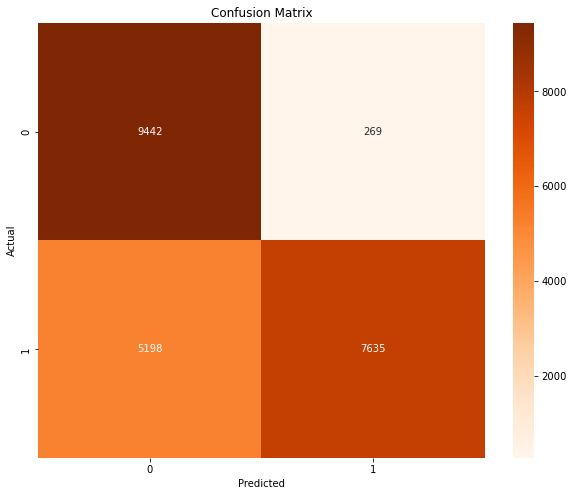

In [142]:
y_test = df_test['attack_binary']
cm = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ROC

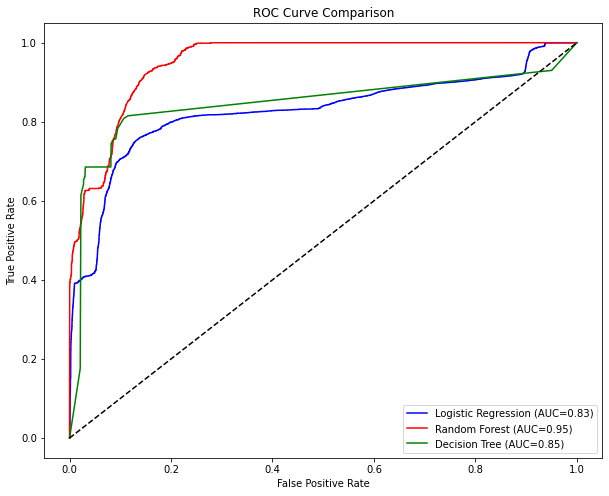

In [146]:
from sklearn.metrics import roc_curve, auc
y_prob_lr = log_reg.predict_proba(X_test_pca)[:, 1] 

y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_lr:.2f})", color='blue')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})", color='red')
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={roc_auc_dt:.2f})", color='green')
plt.plot([0, 1], [0, 1], "k--")  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()



# Box plot

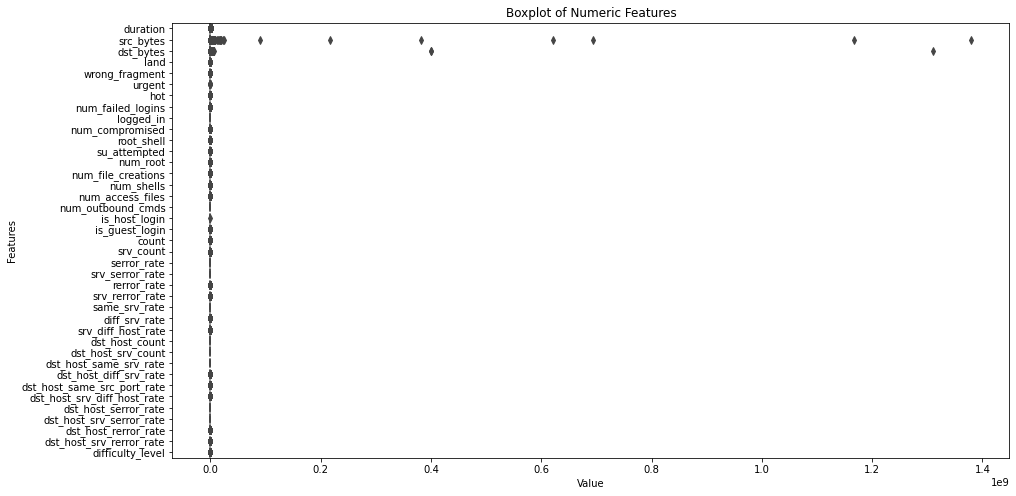

In [163]:
numeric_cols = [col for col in df_train.columns if df_train[col].dtype in ['int64', 'float64'] 
                and col not in ['attack_binary']]  # exclude target

plt.figure(figsize=(15, 8))
sns.boxplot(data=df_train[numeric_cols], orient='h')
plt.title("Boxplot of Numeric Features")
plt.xlabel("Value")
plt.ylabel("Features")
plt.show()



# Correlation HeatMap


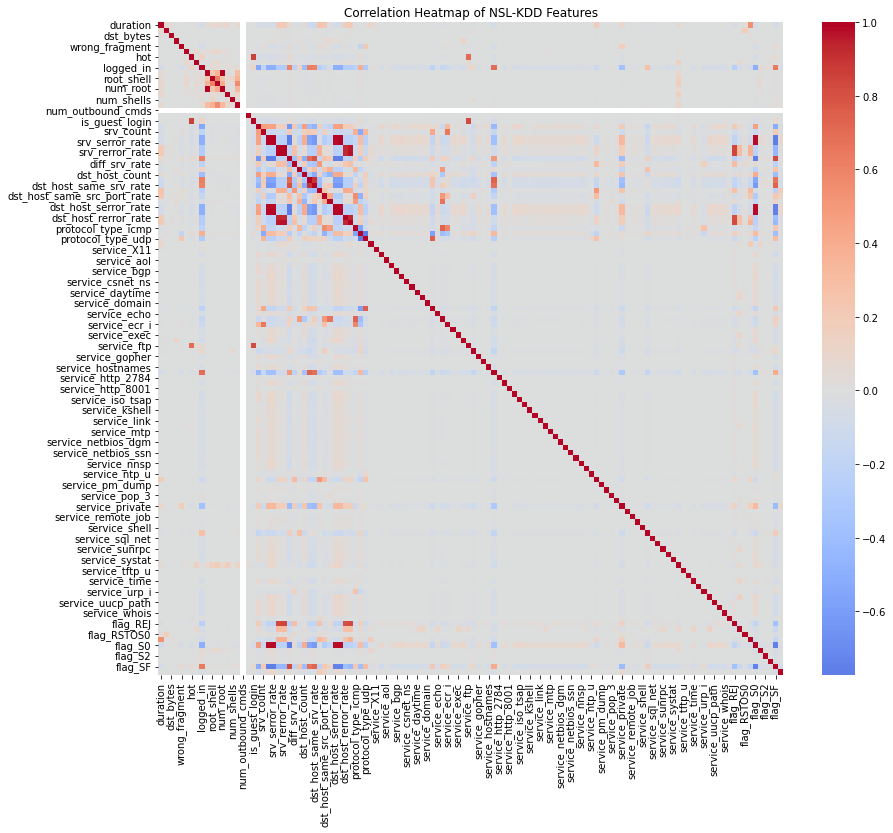

In [166]:
plt.figure(figsize=(14, 12))
corr = X_train_scaled.corr()  
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, fmt=".2f", cbar=True)
plt.title('Correlation Heatmap of NSL-KDD Features')
plt.show()

